Analyze all the numerical data in tips.csv and create data visualizations to derive key insights from them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('tips.csv')

In [4]:
df['tips in percentage']= 100* df['tip'] / df['total_bill']

In [5]:
df

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tips in percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,14.680765
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17,9.820426


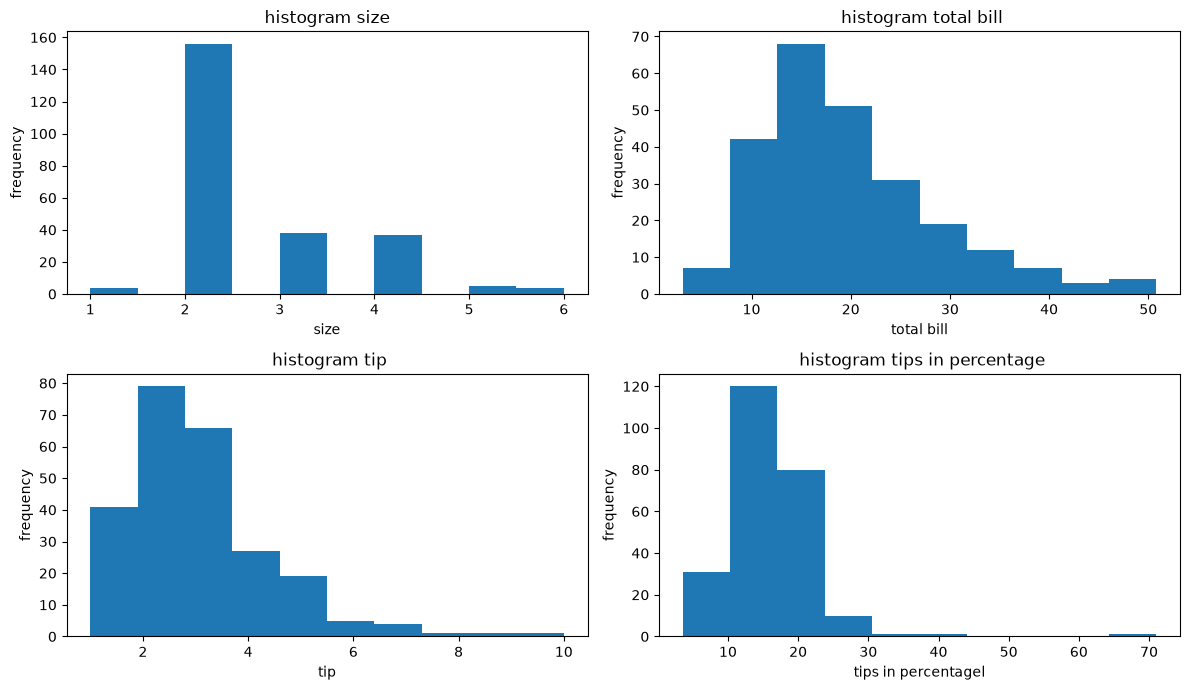

In [7]:
plt.figure(figsize=(12,7))


plt.subplot(2,2,1)
plt.hist(df['size'])
plt.xlabel('size')
plt.ylabel('frequency')
plt.title('histogram size')


plt.subplot(2,2,2)
plt.hist(df['total_bill']) 
plt.xlabel('total bill')
plt.ylabel('frequency')
plt.title(' histogram total bill')

plt.subplot(2,2,3)
plt.hist(df['tip']) 
plt.xlabel('tip')
plt.ylabel('frequency')
plt.title(' histogram tip')

plt.subplot(2,2,4)
plt.hist(df['tips in percentage']) 
plt.xlabel('tips in percentagel')
plt.ylabel('frequency')
plt.title(' histogram tips in percentage')

plt.tight_layout()


plt.show()



Most of the customers came in pairs.Parties of 1, 5, and 6 are rare exceptions in the dataset.

While the tip percentage predictably clusters between 10% and 25% for most transactions, the next section will investigate the anomalies: specifically, the cases with extremely low tips and those exceeding 30%.

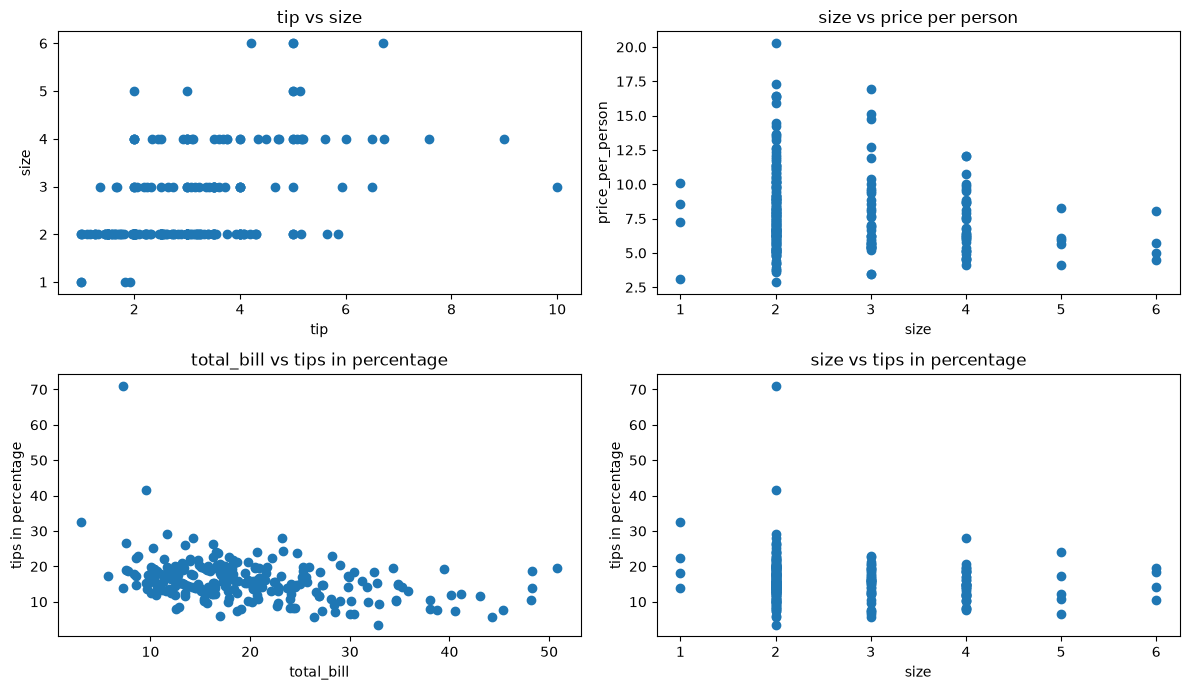

In [14]:
plt.figure(figsize=(12,7))


plt.subplot(2,2,1)
plt.scatter(df['tip'],df['size'])
plt.xlabel('tip')
plt.ylabel('size')
plt.title('tip vs size')

plt.subplot(2,2,2)
plt.scatter(df['size'],df['price_per_person'])
plt.xlabel('size')
plt.ylabel('price_per_person')
plt.title('size vs price per person')

plt.subplot(2,2,3)
plt.scatter(df['total_bill'],df['tips in percentage'])
plt.xlabel('total_bill')
plt.ylabel('tips in percentage')
plt.title('total_bill vs tips in percentage')

plt.subplot(2,2,4)
plt.scatter(df['size'],df['tips in percentage'])
plt.xlabel('size')
plt.ylabel('tips in percentage')
plt.title('size vs tips in percentage')



plt.tight_layout()

plt.show()


In [15]:
df[df['price_per_person'] > 15]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tips in percentage
83,32.68,5.00,Male,Yes,Thur,Lunch,2,16.34,Daniel Murphy,5356177501009133,Thur8801,15.299878
170,50.81,10.00,Male,Yes,Sat,Dinner,3,16.94,Gregory Clark,5473850968388236,Sat1954,19.681165
173,31.85,3.18,Male,Yes,Sun,Dinner,2,15.92,Scott Perez,3577115550328507,Sun9335,9.984301
175,32.90,3.11,Male,Yes,Sun,Dinner,2,16.45,Nathan Reynolds,370307040837149,Sun5109,9.452888
179,34.63,3.55,Male,Yes,Sun,Dinner,2,17.32,Brian Bailey,346656312114848,Sun9851,10.251227
182,45.35,3.50,Male,Yes,Sun,Dinner,3,15.12,Jose Parsons,4112207559459910,Sun2337,7.717751
184,40.55,3.00,Male,Yes,Sun,Dinner,2,20.27,Stephen Cox,3547798222044029,Sun5140,7.398274
237,32.83,1.17,Male,Yes,Sat,Dinner,2,16.42,Thomas Brown,4284722681265508,Sat2929,3.563814


The majority of customers with the highest price per person are men, mostly dining in groups of 2 to 3 for Sunday dinner, and they are all smokers. Perhaps nicotine increases their appetite, and people are happier during Sunday dinner, making them more willing to spend. Furthermore, most of their tip percentages fall within the normal range of 7% to 15%, with occasionally one or two extremely high or low outliers.

Another possibility is that these cases represent couples on dates for weekend dinner. This would explain why men are paying the bills and why the price per person is relatively high, as men tend to be more generous during dates.

In [16]:
df[df['tips in percentage'] < 6]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tips in percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,5.944673
57,26.41,1.50,Female,No,Sat,Dinner,2,13.20,Melody Simon,4745394421258160,Sat8980,5.679667
102,44.30,2.50,Female,Yes,Sat,Dinner,3,14.77,Heather Cohen,379771118886604,Sat6240,5.643341
237,32.83,1.17,Male,Yes,Sat,Dinner,2,16.42,Thomas Brown,4284722681265508,Sat2929,3.563814


The majority of cases with a low tip percentage involve female customers dining during Saturday dinner

In [9]:
df[df['tips in percentage'] > 30]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tips in percentage
67,3.07,1.00,Female,Yes,Sat,Dinner,1,3.07,Tiffany Brock,4359488526995267,Sat3455,32.573290
172,7.25,5.15,Male,Yes,Sun,Dinner,2,3.62,Larry White,30432617123103,Sun9209,71.034483
178,9.60,4.00,Female,Yes,Sun,Dinner,2,4.80,Melanie Gray,4211808859168,Sun4598,41.666667


The high tip percentages are driven by low total bills combined with the fact that these customers are all smokers. These cases typically involve only 1 or 2 diners having weekend dinner.

In [13]:
df[df['size'] > 4]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tips in percentage
125,29.80,4.20,Female,No,Thur,Lunch,6,4.97,Angela Sanchez,503857080488,Thur3948,14.093960
141,34.30,6.70,Male,No,Thur,Lunch,6,5.72,Steven Carlson,3526515703718508,Thur1025,19.533528
142,41.19,5.00,Male,No,Thur,Lunch,5,8.24,Eric Andrews,4356531761046453,Thur3621,12.138869
143,27.05,5.00,Female,No,Thur,Lunch,6,4.51,Regina Jones,4311048695487,Thur6179,18.484288
155,29.85,5.14,Female,No,Sun,Dinner,5,5.97,Madison Wilson,4210875236164664,Sun9176,17.219430
156,48.17,5.00,Male,No,Sun,Dinner,6,8.03,Ryan Gonzales,3523151482063321,Sun7518,10.379905
185,20.69,5.00,Male,No,Sun,Dinner,5,4.14,Joseph Howell,30362407455623,Sun5842,24.166264
187,30.46,2.00,Male,Yes,Sun,Dinner,5,6.09,David Barrett,4792882899700988,Sun9987,6.565988
216,28.15,3.00,Male,Yes,Sat,Dinner,5,5.63,Shawn Barnett PhD,4590982568244,Sat7320,10.657194


For parties of 5 or 6, the tip percentages fall within the normal range. In these larger gatherings, the majority of customers are non-smokers and men, with the timing split equally between weekday lunches and weekend dinners. Interestingly, the price per person remains relatively low; this is likely because larger groups tend to order a wider variety of dishes to share, making the meal more cost-effective.

Maybe men are more likely to pay for large group bills due to social dynamics.